<a href="https://colab.research.google.com/github/shruti-banerjee/menstrual-cycle-transcriptomics/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%load_ext rpy2.ipython

In [3]:
%%R
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")
BiocManager::install("GEOquery", ask = FALSE)
library(GEOquery)
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::combine()    masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
✖ ggplot2::Position() masks BiocGenerics::Position(), base::Position()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/BiocManager_1.30.27.tar.gz'
Content type 'application/x-gzip' length 752490 bytes (734 KB)
downloaded 734 KB


The downloaded source packages are in
	‘/tmp/Rtmpu1diH4/downloaded_packages’
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)
Installing package(s) 'BiocVersion', 'GEOquery'
also installing the dependencies ‘XVector’, ‘matrixStats’, ‘abind’, ‘SparseArray’, ‘BiocGenerics’, ‘statmod’, ‘XML’, ‘R.oo’, ‘R.methodsS3’, ‘MatrixGenerics’, ‘GenomicRanges’, ‘IRanges’, ‘Seqinfo’, ‘S4Arrays’, ‘DelayedArray’, ‘Biobase’, ‘limma’, ‘rentrez’, ‘R.utils’, ‘SummarizedExperiment’, ‘S4Vectors’

trying URL 'https://bioconductor.org/packages/3.23/bioc/src/contrib

In [4]:
%%R
# Load dataset
gse <- getGEO("GSE4888", GSEMatrix = TRUE)
eset <- gse[[1]]

# Check dimensions
cat("Genes:", nrow(eset), "\n")
cat("Samples:", ncol(eset), "\n")

# Look at sample metadata - find cycle phase column
pData(eset)[, c("title", "characteristics_ch1")]

Genes: 54675 
Samples: 27 
                     title         characteristics_ch1
GSM109814  endometrium 598      Proliferative phase PE
GSM109815 endometrium M165      Proliferative phase PE
GSM109816 endometrium M169      Proliferative phase PE
GSM109817 endometrium M182      Proliferative phase PE
GSM109818  endometrium 421 Ambiguous histology reading
GSM109819  endometrium 642 Ambiguous histology reading
GSM109820  endometrium 629   Early secretory phase ESE
GSM109821  endometrium 650   Early secretory phase ESE
GSM109822  endometrium 664   Early secretory phase ESE
GSM109823  endometrium 389 Ambiguous histology reading
GSM109824  endometrium 610     Mid secretory phase MSE
GSM109825  endometrium 617     Mid secretory phase MSE
GSM109826  endometrium 626     Mid secretory phase MSE
GSM109827  endometrium 659     Mid secretory phase MSE
GSM109828 endometrium G98A     Mid secretory phase MSE
GSM109829 endometrium M153     Mid secretory phase MSE
GSM109830 endometrium M158     Mid sec

Found 1 file(s)
GSE4888_series_matrix.txt.gz
|--------------------------------------------------|
|==================================================|
|--------------------------------------------------|
|==================================================|


In [5]:
%%R
library(tidyverse)

# Extract expression matrix and metadata
expr_matrix <- exprs(eset)
metadata <- pData(eset) %>%
  select(title, characteristics_ch1) %>%
  rename(sample = title, phase = characteristics_ch1)

# Remove ambiguous samples - keep only clear cycle phases
clean_metadata <- metadata %>%
  filter(!str_detect(phase, "Ambiguous")) %>%
  mutate(phase = case_when(
    str_detect(phase, "Proliferative") ~ "PE",
    str_detect(phase, "Early secretory") ~ "ESE",
    str_detect(phase, "Mid secretory") ~ "MSE",
    str_detect(phase, "Late secretory") ~ "LSE"
  ))

# Check how many samples we have per phase
clean_metadata %>% count(phase)

  phase n
1   ESE 3
2   LSE 6
3   MSE 8
4    PE 4


In [6]:
%%R
# Keep only clean samples in expression matrix
clean_samples <- rownames(clean_metadata)
clean_expr <- expr_matrix[, clean_samples]

# Verify dimensions
cat("Genes:", nrow(clean_expr), "\n")
cat("Clean samples:", ncol(clean_expr), "\n")

# Quick check - are expression values log transformed?
cat("Min expression value:", min(clean_expr), "\n")
cat("Max expression value:", max(clean_expr), "\n")
cat("Mean expression value:", mean(clean_expr), "\n")

Genes: 54675 
Clean samples: 21 
Min expression value: 7.614542 
Max expression value: 21599.82 
Mean expression value: 203.132 


In [7]:
%%R
# Log2 transform the expression matrix
clean_expr_log <- log2(clean_expr)

# Verify transformation worked
cat("Min after log2:", min(clean_expr_log), "\n")
cat("Max after log2:", max(clean_expr_log), "\n")
cat("Mean after log2:", mean(clean_expr_log), "\n")

Min after log2: 2.928757 
Max after log2: 14.39873 
Mean after log2: 6.233711 


In [9]:
%%R
# Prepare data for plotting - fixed version
expr_df <- as.data.frame(clean_expr_log)
expr_df$gene <- rownames(expr_df)

expr_long <- expr_df %>%
  pivot_longer(-gene, names_to = "sample", values_to = "expression") %>%
  left_join(clean_metadata %>%
              rownames_to_column("sample_id") %>%
              rename(sample = sample_id),
            by = "sample")

# QC Boxplot
ggplot(expr_long, aes(x = sample, y = expression, fill = phase)) +
  geom_boxplot(outlier.size = 0.3) +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, size = 7)) +
  labs(
    title = "Gene Expression Distribution Across Samples",
    subtitle = "GSE4888 — Menstrual Cycle Phases",
    x = "Sample",
    y = "Log2 Expression",
    fill = "Cycle Phase"
  ) +
  scale_fill_manual(values = c(
    "PE" = "#4E9AF1",
    "ESE" = "#F4A261",
    "MSE" = "#2A9D8F",
    "LSE" = "#E76F51"
  ))

Error in `rename()`:
! Names must be unique.
✖ These names are duplicated:
  * "sample" at locations 1 and 2.
Run `rlang::last_trace()` to see where the error occurred.

Error in rename(., sample = sample_id) :


RInterpreterError: Failed to parse and evaluate line '# Prepare data for plotting - fixed version\nexpr_df <- as.data.frame(clean_expr_log)\nexpr_df$gene <- rownames(expr_df)\n\nexpr_long <- expr_df %>%\n  pivot_longer(-gene, names_to = "sample", values_to = "expression") %>%\n  left_join(clean_metadata %>% \n              rownames_to_column("sample_id") %>%\n              rename(sample = sample_id), \n            by = "sample")\n\n# QC Boxplot\nggplot(expr_long, aes(x = sample, y = expression, fill = phase)) +\n  geom_boxplot(outlier.size = 0.3) +\n  theme_classic() +\n  theme(axis.text.x = element_text(angle = 90, hjust = 1, size = 7)) +\n  labs(\n    title = "Gene Expression Distribution Across Samples",\n    subtitle = "GSE4888 — Menstrual Cycle Phases",\n    x = "Sample",\n    y = "Log2 Expression",\n    fill = "Cycle Phase"\n  ) +\n  scale_fill_manual(values = c(\n    "PE" = "#4E9AF1",\n    "ESE" = "#F4A261",\n    "MSE" = "#2A9D8F",\n    "LSE" = "#E76F51"\n  ))\n'.
R error messag

In [10]:
%%R
# Check column names in metadata first
colnames(clean_metadata)

[1] "sample" "phase" 


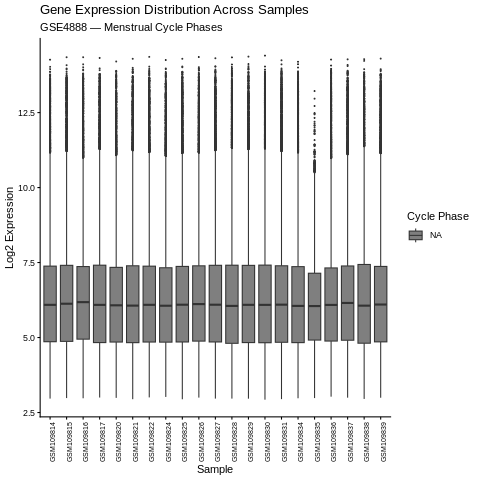

In [11]:
%%R
# Prepare data for plotting - fixed version
expr_df <- as.data.frame(clean_expr_log)
expr_df$gene <- rownames(expr_df)

expr_long <- expr_df %>%
  pivot_longer(-gene, names_to = "sample_id", values_to = "expression") %>%
  left_join(clean_metadata, by = c("sample_id" = "sample"))

# QC Boxplot
ggplot(expr_long, aes(x = sample_id, y = expression, fill = phase)) +
  geom_boxplot(outlier.size = 0.3) +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, size = 7)) +
  labs(
    title = "Gene Expression Distribution Across Samples",
    subtitle = "GSE4888 — Menstrual Cycle Phases",
    x = "Sample",
    y = "Log2 Expression",
    fill = "Cycle Phase"
  ) +
  scale_fill_manual(values = c(
    "PE" = "#4E9AF1",
    "ESE" = "#F4A261",
    "MSE" = "#2A9D8F",
    "LSE" = "#E76F51"
  ))

In [12]:
%%R
# Check what sample IDs look like in each object
cat("Expression matrix column names (first 3):\n")
print(colnames(clean_expr_log)[1:3])

cat("\nMetadata sample column (first 3):\n")
print(clean_metadata$sample[1:3])

Expression matrix column names (first 3):
[1] "GSM109814" "GSM109815" "GSM109816"

Metadata sample column (first 3):
[1] "endometrium 598"  "endometrium M165" "endometrium M169"


In [13]:
%%R
# Check rownames of clean_metadata
print(rownames(clean_metadata)[1:3])

[1] "GSM109814" "GSM109815" "GSM109816"


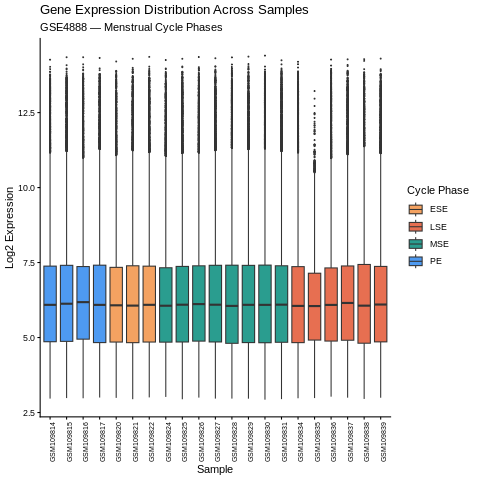

In [14]:
%%R
# Fix metadata to use GSM IDs as the join key
clean_metadata_fixed <- clean_metadata %>%
  mutate(gsm_id = rownames(clean_metadata))

# Prepare expression data
expr_df <- as.data.frame(clean_expr_log)
expr_df$gene <- rownames(expr_df)

expr_long <- expr_df %>%
  pivot_longer(-gene, names_to = "gsm_id", values_to = "expression") %>%
  left_join(clean_metadata_fixed, by = "gsm_id")

# QC Boxplot
ggplot(expr_long, aes(x = gsm_id, y = expression, fill = phase)) +
  geom_boxplot(outlier.size = 0.3) +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, size = 7)) +
  labs(
    title = "Gene Expression Distribution Across Samples",
    subtitle = "GSE4888 — Menstrual Cycle Phases",
    x = "Sample",
    y = "Log2 Expression",
    fill = "Cycle Phase"
  ) +
  scale_fill_manual(values = c(
    "PE" = "#4E9AF1",
    "ESE" = "#F4A261",
    "MSE" = "#2A9D8F",
    "LSE" = "#E76F51"
  ))

In [15]:
%%R
ggsave("qc_boxplot.png", width = 10, height = 6, dpi = 300)

In [16]:
%%R
# Calculate variance for each gene across all samples
gene_variance <- apply(clean_expr_log, 1, var)

# Select top 500 most variable genes
top_500_genes <- names(sort(gene_variance, decreasing = TRUE)[1:500])

# Subset expression matrix to top 500 genes
expr_top500 <- clean_expr_log[top_500_genes, ]

cat("Selected", nrow(expr_top500), "most variable genes\n")
cat("Across", ncol(expr_top500), "samples\n")

Selected 500 most variable genes
Across 21 samples


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/pheatmap_1.0.13.tar.gz'
Content type 'application/x-gzip' length 15162 bytes (14 KB)
downloaded 14 KB


The downloaded source packages are in
	‘/tmp/Rtmpu1diH4/downloaded_packages’


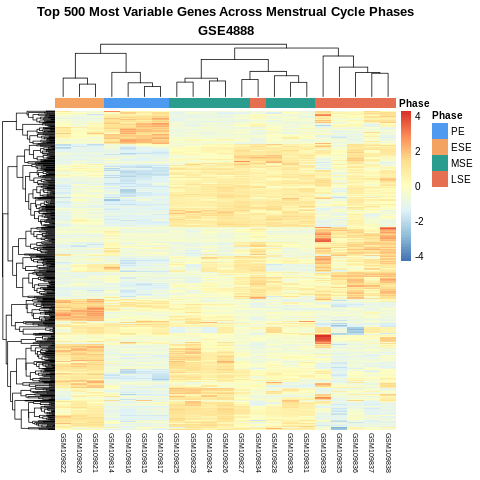

In [17]:
%%R
install.packages("pheatmap")
library(pheatmap)

# Create annotation for samples showing cycle phase
annotation_col <- data.frame(
  Phase = clean_metadata_fixed$phase,
  row.names = clean_metadata_fixed$gsm_id
)

# Define phase colours
annotation_colors <- list(
  Phase = c(
    "PE"  = "#4E9AF1",
    "ESE" = "#F4A261",
    "MSE" = "#2A9D8F",
    "LSE" = "#E76F51"
  )
)

# Plot heatmap
pheatmap(
  expr_top500,
  annotation_col = annotation_col,
  annotation_colors = annotation_colors,
  show_rownames = FALSE,
  show_colnames = TRUE,
  scale = "row",
  clustering_distance_rows = "euclidean",
  clustering_distance_cols = "euclidean",
  clustering_method = "complete",
  fontsize_col = 7,
  main = "Top 500 Most Variable Genes Across Menstrual Cycle Phases\nGSE4888"
)

png 
  3 


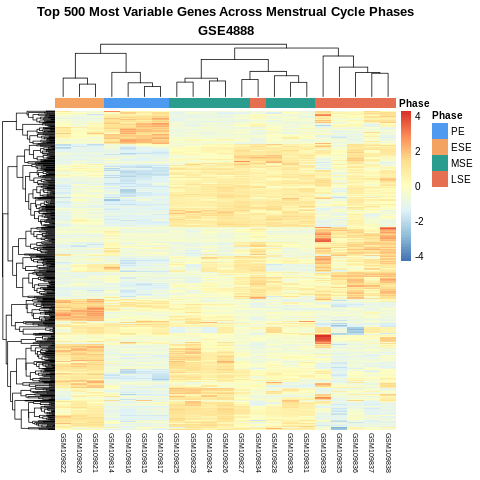

In [18]:
%%R
png("heatmap_top500.png", width = 2400, height = 3000, res = 300)
pheatmap(
  expr_top500,
  annotation_col = annotation_col,
  annotation_colors = annotation_colors,
  show_rownames = FALSE,
  show_colnames = TRUE,
  scale = "row",
  clustering_distance_rows = "euclidean",
  clustering_distance_cols = "euclidean",
  clustering_method = "complete",
  fontsize_col = 7,
  main = "Top 500 Most Variable Genes Across Menstrual Cycle Phases\nGSE4888"
)
dev.off()

In [19]:
%%R
BiocManager::install("limma", ask = FALSE)
library(limma)

# Set up comparison - PE vs LSE only
keep_samples <- clean_metadata_fixed %>%
  filter(phase %in% c("PE", "LSE"))

expr_PE_LSE <- clean_expr_log[, keep_samples$gsm_id]

# Create design matrix
phase_factor <- factor(keep_samples$phase, levels = c("PE", "LSE"))
design <- model.matrix(~phase_factor)

# Fit linear model
fit <- lmFit(expr_PE_LSE, design)
fit <- eBayes(fit)

# Get results
results <- topTable(fit, coef = 2, number = Inf, adjust.method = "BH")

# Summary
cat("Total genes tested:", nrow(results), "\n")
cat("Significant DEGs (p < 0.05, |FC| > 1.5):",
    sum(results$adj.P.Val < 0.05 & abs(results$logFC) > log2(1.5)), "\n")

Total genes tested: 54675 
Significant DEGs (p < 0.05, |FC| > 1.5): 3386 


'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Attaching package: ‘limma’

The following object is masked from ‘package:BiocGenerics’:

    plotMA

In addition: Warning message:
package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'limma' 


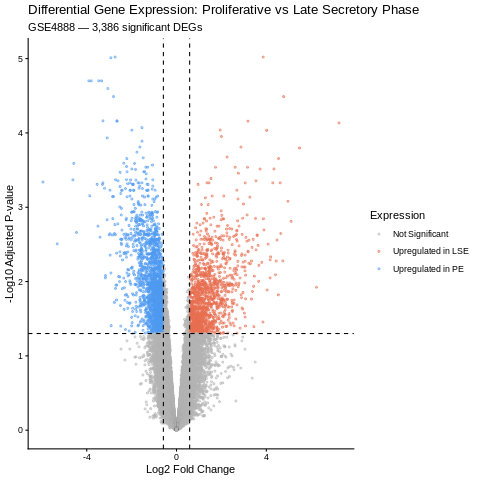

In [20]:
%%R
# Prepare volcano plot data
volcano_data <- results %>%
  mutate(
    significance = case_when(
      adj.P.Val < 0.05 & logFC > log2(1.5)  ~ "Upregulated in LSE",
      adj.P.Val < 0.05 & logFC < -log2(1.5) ~ "Upregulated in PE",
      TRUE ~ "Not Significant"
    )
  )

# Volcano plot
ggplot(volcano_data, aes(x = logFC, y = -log10(adj.P.Val), colour = significance)) +
  geom_point(alpha = 0.5, size = 0.8) +
  scale_colour_manual(values = c(
    "Upregulated in LSE" = "#E76F51",
    "Upregulated in PE"  = "#4E9AF1",
    "Not Significant"    = "grey70"
  )) +
  geom_vline(xintercept = c(-log2(1.5), log2(1.5)), linetype = "dashed", colour = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", colour = "black") +
  theme_classic() +
  labs(
    title = "Differential Gene Expression: Proliferative vs Late Secretory Phase",
    subtitle = "GSE4888 — 3,386 significant DEGs",
    x = "Log2 Fold Change",
    y = "-Log10 Adjusted P-value",
    colour = "Expression"
  )

In [21]:
%%R
ggsave("volcano_PE_vs_LSE.png", width = 10, height = 7, dpi = 300)

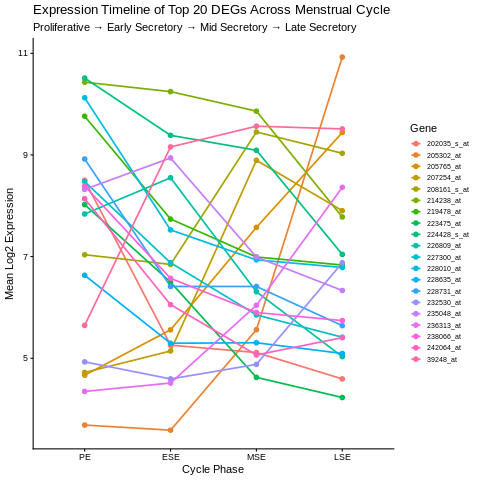

In [22]:
%%R
# Get top 20 most significant DEGs
top20_genes <- rownames(results[order(results$adj.P.Val), ])[1:20]

# Prepare data for timeline
timeline_data <- as.data.frame(clean_expr_log[top20_genes, ]) %>%
  rownames_to_column("gene") %>%
  pivot_longer(-gene, names_to = "gsm_id", values_to = "expression") %>%
  left_join(clean_metadata_fixed, by = "gsm_id") %>%
  mutate(phase = factor(phase, levels = c("PE", "ESE", "MSE", "LSE")))

# Calculate mean expression per gene per phase
timeline_summary <- timeline_data %>%
  group_by(gene, phase) %>%
  summarise(mean_expr = mean(expression), .groups = "drop")

# Plot
ggplot(timeline_summary, aes(x = phase, y = mean_expr,
                              group = gene, colour = gene)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  theme_classic() +
  theme(legend.text = element_text(size = 7),
        legend.key.size = unit(0.4, "cm")) +
  labs(
    title = "Expression Timeline of Top 20 DEGs Across Menstrual Cycle",
    subtitle = "Proliferative → Early Secretory → Mid Secretory → Late Secretory",
    x = "Cycle Phase",
    y = "Mean Log2 Expression",
    colour = "Gene"
  )

In [23]:
%%R
ggsave("expression_timeline_top20.png", width = 10, height = 7, dpi = 300)

png 
  3 


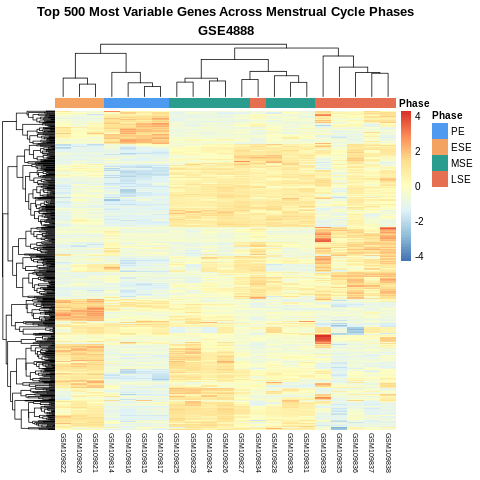

In [24]:
%%R
# Resave heatmap using recordPlot approach
png("heatmap_top500.png", width = 2400, height = 3000, res = 300)
pheatmap(
  expr_top500,
  annotation_col = annotation_col,
  annotation_colors = annotation_colors,
  show_rownames = FALSE,
  show_colnames = TRUE,
  scale = "row",
  clustering_distance_rows = "euclidean",
  clustering_distance_cols = "euclidean",
  clustering_method = "complete",
  fontsize_col = 7,
  main = "Top 500 Most Variable Genes Across Menstrual Cycle Phases\nGSE4888"
)
dev.off()

png 
  3 


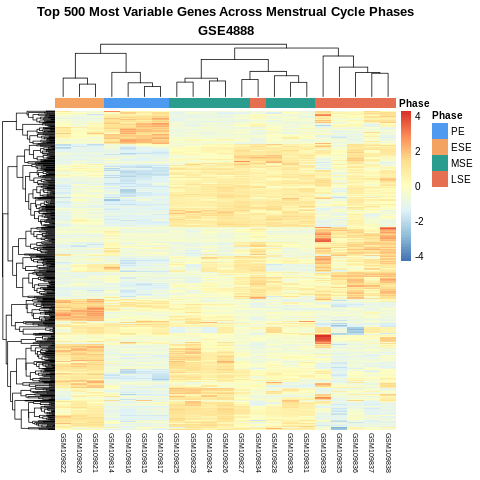

In [25]:
%%R
png("heatmap_top500.png", width = 2400, height = 3000, res = 300)
pheatmap(
  expr_top500,
  annotation_col = annotation_col,
  annotation_colors = annotation_colors,
  show_rownames = FALSE,
  show_colnames = TRUE,
  scale = "row",
  clustering_distance_rows = "euclidean",
  clustering_distance_cols = "euclidean",
  clustering_method = "complete",
  fontsize_col = 7,
  main = "Top 500 Most Variable Genes Across Menstrual Cycle Phases\nGSE4888"
)
dev.off()

In [26]:
%%R
library(grid)

# Draw and save heatmap
p <- pheatmap(
  expr_top500,
  annotation_col = annotation_col,
  annotation_colors = annotation_colors,
  show_rownames = FALSE,
  show_colnames = TRUE,
  scale = "row",
  clustering_distance_rows = "euclidean",
  clustering_distance_cols = "euclidean",
  clustering_method = "complete",
  fontsize_col = 7,
  main = "Top 500 Most Variable Genes Across Menstrual Cycle Phases\nGSE4888",
  silent = TRUE
)

ggsave("heatmap_top500.png", plot = p$gtable,
       width = 10, height = 12, dpi = 300)

In [27]:
%%R
# Top 20 DEGs with their fold changes
top20_results <- results[order(results$adj.P.Val), ][1:20, c("logFC", "AveExpr", "adj.P.Val")]
print(top20_results)

                logFC  AveExpr    adj.P.Val
39248_at     3.864889 7.966278 9.541713e-06
242064_at   -2.733014 6.498793 9.541713e-06
219478_at   -2.927969 8.004931 9.711580e-06
202035_s_at -3.907520 6.156073 1.991032e-05
228010_at   -3.338818 8.121558 1.991032e-05
223475_at   -3.794768 5.745364 1.991032e-05
224428_s_at -3.468559 8.431261 1.991032e-05
227300_at   -3.060586 6.637908 2.524496e-05
226809_at   -2.806443 6.154576 3.246646e-05
205765_at    4.774372 7.531933 3.246646e-05
214238_at   -2.651533 8.840582 6.872175e-05
228731_at   -3.278104 6.952805 6.872175e-05
207254_at    3.182535 6.629781 6.958872e-05
238066_at   -2.647735 6.799632 6.958872e-05
205302_at    7.240228 8.029405 7.321742e-05
228635_at   -1.538203 5.709349 8.480311e-05
232530_at    1.949557 6.098652 9.140022e-05
235048_at   -1.990436 7.129244 9.230973e-05
236313_at    4.014956 6.756522 9.230973e-05
208161_s_at  1.996006 8.233996 1.115238e-04


In [28]:
%%R
# How many genes up vs down
up_in_LSE <- sum(results$adj.P.Val < 0.05 & results$logFC > log2(1.5))
up_in_PE <- sum(results$adj.P.Val < 0.05 & results$logFC < -log2(1.5))
cat("Upregulated in LSE:", up_in_LSE, "\n")
cat("Upregulated in PE:", up_in_PE, "\n")

Upregulated in LSE: 1357 
Upregulated in PE: 2029 


In [29]:
%%R
BiocManager::install("hgu133plus2.db", ask = FALSE)
library(hgu133plus2.db)

# Map probe IDs to gene symbols
top20_probes <- rownames(results[order(results$adj.P.Val), ])[1:20]
gene_symbols <- mapIds(hgu133plus2.db,
                       keys = top20_probes,
                       column = "SYMBOL",
                       keytype = "PROBEID",
                       multiVals = "first")

# Combine with results
top20_annotated <- data.frame(
  probe = top20_probes,
  symbol = gene_symbols,
  logFC = results[top20_probes, "logFC"],
  adj.P.Val = results[top20_probes, "adj.P.Val"]
)
print(top20_annotated)

                  probe   symbol     logFC    adj.P.Val
39248_at       39248_at     AQP3  3.864889 9.541713e-06
242064_at     242064_at     SDK2 -2.733014 9.541713e-06
219478_at     219478_at    WFDC1 -2.927969 9.711580e-06
202035_s_at 202035_s_at    SFRP1 -3.907520 1.991032e-05
228010_at     228010_at  PPP2R2C -3.338818 1.991032e-05
223475_at     223475_at CRISPLD1 -3.794768 1.991032e-05
224428_s_at 224428_s_at    CDCA7 -3.468559 1.991032e-05
227300_at     227300_at  TMEM119 -3.060586 2.524496e-05
226809_at     226809_at   FAR2P2 -2.806443 3.246646e-05
205765_at     205765_at   CYP3A5  4.774372 3.246646e-05
214238_at     214238_at     GDF7 -2.651533 6.872175e-05
228731_at     228731_at  GUCY1A2 -3.278104 6.872175e-05
207254_at     207254_at  SLC15A1  3.182535 6.958872e-05
238066_at     238066_at     RBP7 -2.647735 6.958872e-05
205302_at     205302_at   IGFBP1  7.240228 7.321742e-05
228635_at     228635_at   PCDH10 -1.538203 8.480311e-05
232530_at     232530_at     PLD1  1.949557 9.140

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)
Installing package(s) 'hgu133plus2.db'
also installing the dependencies ‘png’, ‘Biostrings’, ‘RSQLite’, ‘KEGGREST’, ‘AnnotationDbi’, ‘org.Hs.eg.db’

trying URL 'https://cran.rstudio.com/src/contrib/png_0.1-9.tar.gz'
trying URL 'https://bioconductor.org/packages/3.23/bioc/src/contrib/Biostrings_2.80.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/RSQLite_3.53.1.tar.gz'
trying URL 'https://bioconductor.org/packages/3.23/bioc/src/contrib/KEGGREST_1.52.0.tar.gz'
trying URL 'https://bioconductor.org/packages/3.23/bioc/src/contrib/AnnotationDbi_1.74.0.tar.gz'
trying URL 'https://bioconductor.org/packages/3.23/data/annotation/src/contrib/org.Hs.eg.db_3.23.1.tar.gz'
trying URL 'https://bioconductor.org/packages/3.23/data/anno

In [30]:
%%R
BiocManager::install("clusterProfiler", ask = FALSE)
BiocManager::install("org.Hs.eg.db", ask = FALSE)
library(clusterProfiler)
library(org.Hs.eg.db)

# Get significant DEGs
sig_genes <- results %>%
  filter(adj.P.Val < 0.05 & abs(logFC) > log2(1.5)) %>%
  rownames_to_column("probe")

# Map probe IDs to Entrez IDs
entrez_ids <- mapIds(hgu133plus2.db,
                     keys = sig_genes$probe,
                     column = "ENTREZID",
                     keytype = "PROBEID",
                     multiVals = "first")

# Remove NAs
entrez_ids <- entrez_ids[!is.na(entrez_ids)]

cat("Genes mapped to Entrez IDs:", length(entrez_ids), "\n")

Genes mapped to Entrez IDs: 3141 


'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)
Installing package(s) 'clusterProfiler'
also installing the dependencies ‘fontBitstreamVera’, ‘fontLiberation’, ‘fontquiver’, ‘gridGraphics’, ‘gdtools’, ‘lazyeval’, ‘tweenr’, ‘polyclip’, ‘ggplotify’, ‘patchwork’, ‘ape’, ‘ggiraph’, ‘tidytree’, ‘treeio’, ‘ggforce’, ‘aplot’, ‘DOSE’, ‘ggfun’, ‘ggnewscale’, ‘ggrepel’, ‘ggtangle’, ‘ggtree’, ‘reshape2’, ‘scatterpie’, ‘tidydr’, ‘aisdk’, ‘enrichit’, ‘enrichplot’, ‘GO.db’, ‘GOSemSim’, ‘gson’, ‘igraph’, ‘plyr’, ‘qvalue’, ‘yulab.utils’

trying URL 'https://cran.rstudio.com/src/contrib/fontBitstreamVera_0.1.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/fontLiberation_0.1.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/fontquiver_0.2.1.tar.gz'
trying URL 'https://cran.

In [31]:
%%R
# GO Biological Process enrichment
go_enrichment <- enrichGO(
  gene = entrez_ids,
  OrgDb = org.Hs.eg.db,
  ont = "BP",
  pAdjustMethod = "BH",
  pvalueCutoff = 0.05,
  qvalueCutoff = 0.05,
  readable = TRUE
)

cat("Significant GO terms found:", nrow(go_enrichment@result), "\n")

# KEGG pathway enrichment
kegg_enrichment <- enrichKEGG(
  gene = entrez_ids,
  organism = "hsa",
  pAdjustMethod = "BH",
  pvalueCutoff = 0.05
)

cat("Significant KEGG pathways found:", nrow(kegg_enrichment@result), "\n")

Significant GO terms found: 5880 
Significant KEGG pathways found: 351 


Reading KEGG annotation online: "https://rest.kegg.jp/link/hsa/pathway"...
Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/hsa"...
kegg_category.rda is not found, download it online...


In [32]:
%%R
# Top 20 GO terms dotplot
dotplot(go_enrichment, showCategory = 20,
        title = "Top 20 GO Biological Processes\nProliferative vs Late Secretory Phase") +
  theme(axis.text.y = element_text(size = 8))

ggsave("go_dotplot.png", width = 10, height = 8, dpi = 300)

In [33]:
%%R
# Top 20 KEGG pathways
barplot(kegg_enrichment, showCategory = 20,
        title = "Top 20 KEGG Pathways\nProliferative vs Late Secretory Phase") +
  theme(axis.text.y = element_text(size = 8))

ggsave("kegg_barplot.png", width = 10, height = 8, dpi = 300)

In [34]:
%%R
# Function to run DEA between any two phases
run_DEA <- function(phase1, phase2) {
  samples <- clean_metadata_fixed %>%
    filter(phase %in% c(phase1, phase2))

  expr <- clean_expr_log[, samples$gsm_id]
  factor_phase <- factor(samples$phase, levels = c(phase1, phase2))
  design <- model.matrix(~factor_phase)

  fit <- lmFit(expr, design)
  fit <- eBayes(fit)

  res <- topTable(fit, coef = 2, number = Inf, adjust.method = "BH")

  sig <- sum(res$adj.P.Val < 0.05 & abs(res$logFC) > log2(1.5))
  up <- sum(res$adj.P.Val < 0.05 & res$logFC > log2(1.5))
  down <- sum(res$adj.P.Val < 0.05 & res$logFC < -log2(1.5))

  cat(phase1, "vs", phase2, "— DEGs:", sig, "| Up in", phase2, ":", up, "| Up in", phase1, ":", down, "\n")
  return(res)
}

# Run all pairwise comparisons
res_PE_ESE  <- run_DEA("PE", "ESE")
res_ESE_MSE <- run_DEA("ESE", "MSE")
res_MSE_LSE <- run_DEA("MSE", "LSE")
res_PE_MSE  <- run_DEA("PE", "MSE")
res_PE_LSE2 <- run_DEA("PE", "LSE")
res_ESE_LSE <- run_DEA("ESE", "LSE")

PE vs ESE — DEGs: 3668 | Up in ESE : 2090 | Up in PE : 1578 
ESE vs MSE — DEGs: 2574 | Up in MSE : 1196 | Up in ESE : 1378 
MSE vs LSE — DEGs: 2314 | Up in LSE : 1079 | Up in MSE : 1235 
PE vs MSE — DEGs: 4653 | Up in MSE : 2572 | Up in PE : 2081 
PE vs LSE — DEGs: 3386 | Up in LSE : 1357 | Up in PE : 2029 
ESE vs LSE — DEGs: 2920 | Up in LSE : 984 | Up in ESE : 1936 


In [35]:
%%R
# Visualise all pairwise DEG counts
comparison_data <- data.frame(
  comparison = c("PE vs ESE", "ESE vs MSE", "MSE vs LSE",
                 "PE vs MSE", "PE vs LSE", "ESE vs LSE"),
  total_DEGs = c(3668, 2574, 2314, 4653, 3386, 2920)
)

ggplot(comparison_data, aes(x = reorder(comparison, total_DEGs),
                             y = total_DEGs, fill = total_DEGs)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = total_DEGs), hjust = -0.2, size = 4) +
  coord_flip() +
  scale_fill_gradient(low = "#4E9AF1", high = "#E76F51") +
  theme_classic() +
  theme(legend.position = "none") +
  labs(
    title = "Transcriptomic Distance Between Cycle Phases",
    subtitle = "Number of significant DEGs per pairwise comparison",
    x = "Phase Comparison",
    y = "Number of DEGs"
  ) +
  ylim(0, 5500)

ggsave("pairwise_DEG_counts.png", width = 10, height = 6, dpi = 300)

In [36]:
%%R
install.packages("igraph")
library(igraph)

# Get top 50 most significant DEGs with gene symbols
top50_probes <- rownames(results[order(results$adj.P.Val), ])[1:50]
top50_symbols <- mapIds(hgu133plus2.db,
                        keys = top50_probes,
                        column = "SYMBOL",
                        keytype = "PROBEID",
                        multiVals = "first")
top50_symbols <- top50_symbols[!is.na(top50_symbols)]

cat("Top 50 gene symbols:\n")
cat(paste(top50_symbols, collapse = ", "), "\n")

Top 50 gene symbols:
AQP3, SDK2, WFDC1, SFRP1, PPP2R2C, CRISPLD1, CDCA7, TMEM119, FAR2P2, CYP3A5, GDF7, GUCY1A2, SLC15A1, RBP7, IGFBP1, PCDH10, PLD1, FAM169A, CDKN2B, ABCC3, EDN3, NEURL1B, ASIC2, MAP3K5, C2CD4A, PIK3R3, GABRE, ANO4, PABPC4L, DEPP1, NREP, SFRP1, TMEM97, DYNLL2, ANO4, IRS2, AGMAT, IRAG1, IRS2, CCDC74A, G0S2, CYP3A5, HOXA10, CLCN5, QDPR, PCSK5, KIAA1210, SNX10, CSRNP3 


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/igraph_2.3.2.tar.gz'
Content type 'application/x-gzip' length 5209216 bytes (5.0 MB)
downloaded 5.0 MB


The downloaded source packages are in
	‘/tmp/Rtmpu1diH4/downloaded_packages’

Attaching package: ‘igraph’

The following object is masked from ‘package:clusterProfiler’:

    simplify

The following object is masked from ‘package:IRanges’:

    union

The following object is masked from ‘package:S4Vectors’:

    union

The following objects are masked from ‘package:lubridate’:

    %--%, union

The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union

The following objects are masked from ‘package:purrr’:

    compose, simplify

The following object is masked from ‘package:tidyr’:

    crossing

The following object is masked from ‘package:tibble’:

    as_data_frame

The following objects are masked from ‘package:BiocGene

In [37]:
%%R
cat("Top 50 gene symbols:\n")
for (gene in top50_symbols) {
  cat(gene, "\n")
}

Top 50 gene symbols:
AQP3 
SDK2 
WFDC1 
SFRP1 
PPP2R2C 
CRISPLD1 
CDCA7 
TMEM119 
FAR2P2 
CYP3A5 
GDF7 
GUCY1A2 
SLC15A1 
RBP7 
IGFBP1 
PCDH10 
PLD1 
FAM169A 
CDKN2B 
ABCC3 
EDN3 
NEURL1B 
ASIC2 
MAP3K5 
C2CD4A 
PIK3R3 
GABRE 
ANO4 
PABPC4L 
DEPP1 
NREP 
SFRP1 
TMEM97 
DYNLL2 
ANO4 
IRS2 
AGMAT 
IRAG1 
IRS2 
CCDC74A 
G0S2 
CYP3A5 
HOXA10 
CLCN5 
QDPR 
PCSK5 
KIAA1210 
SNX10 
CSRNP3 


In [38]:
%%R
library(igraph)

# Clean unique gene symbols
genes <- unique(c("AQP3", "SDK2", "WFDC1", "SFRP1", "PPP2R2C", "CRISPLD1",
                  "CDCA7", "TMEM119", "CYP3A5", "GDF7", "GUCY1A2", "SLC15A1",
                  "RBP7", "IGFBP1", "PCDH10", "PLD1", "CDKN2B", "ABCC3",
                  "EDN3", "MAP3K5", "PIK3R3", "IRS2", "G0S2", "HOXA10",
                  "CLCN5", "PCSK5", "DEPP1", "NREP", "TMEM97", "DYNLL2"))

# Query STRING via API
gene_string <- paste(genes, collapse = "%0d")
string_url <- paste0(
  "https://string-db.org/api/tsv/network?identifiers=",
  gene_string,
  "&species=9606&required_score=400"
)

network_data <- read.delim(url(string_url))
cat("Interactions found:", nrow(network_data), "\n")
head(network_data[, c("preferredName_A", "preferredName_B", "score")])

Interactions found: 6 
  preferredName_A preferredName_B score
1          CYP3A5           ABCC3 0.420
2          PIK3R3            RBP7 0.420
3          PIK3R3            IRS2 0.972
4          IGFBP1            IRS2 0.483
5          IGFBP1          HOXA10 0.522
6           ABCC3         SLC15A1 0.541


In [39]:
%%R
# Build and plot network
edges <- data.frame(
  from = network_data$preferredName_A,
  to = network_data$preferredName_B,
  weight = network_data$score
)

g <- graph_from_data_frame(edges, directed = FALSE)

# Node colours
up_LSE <- c("AQP3", "CYP3A5", "IGFBP1", "ABCC3", "SLC15A1")
V(g)$color <- ifelse(V(g)$name %in% up_LSE, "#FF3366", "#00C2FF")

# Node size based on degree
V(g)$size <- 25 + degree(g) * 8

# Plot
png("ppi_network.png", width = 2000, height = 1800, res = 300)
par(bg = "#0D1117")  # dark background
plot(g,
     vertex.size = V(g)$size,
     vertex.label.cex = 0.75,
     vertex.label.color = "white",
     vertex.label.font = 2,
     vertex.frame.color = NA,
     edge.width = E(g)$weight * 4,
     edge.color = "#FFFFFF50",
     layout = layout_with_fr(g),
     main = "")
title(main = "Protein-Protein Interaction Network\nTop DEGs — PE vs LSE",
      col.main = "white", cex.main = 1.1)
legend("bottomleft",
       legend = c("Upregulated in LSE", "Upregulated in PE"),
       fill = c("#FF3366", "#00C2FF"),
       text.col = "white",
       bty = "n",
       cex = 0.75)
dev.off()

png 
  2 
